In [1]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_qsphere
from qiskit.visualization import plot_bloch_multivector
from qiskit.visualization import plot_histogram
from qiskit_aer import Aer
from qiskit import transpile

# 0. Recapping Math

### 0.1 Complex Number Space

Remember for the $x$-axis (real component) and $y$-axis (imaginary component),

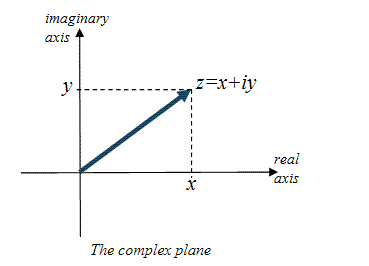

This can be represented as a $2\times2$ matrix, where $(x, y) = (a, b)$,

$z = a + bi \; \widehat{=} \begin{bmatrix}a & -b \\ b & a \end{bmatrix}$

### 0.2 Denoting as 3-Dimensional Space in $2\times2$

Using the Pauli matrices to denote $\vec{v}=(x,y,z)$, we get,

$\rho = x\sigma_1 + y\sigma_2 + z\sigma_3$

In which the Pauli matrices can be denoted as,

$\sigma_1 = \begin{bmatrix}0 & 1 \\ 1 & 0 \end{bmatrix}$, $\sigma_2 = \begin{bmatrix}0 & -i \\ i & 0 \end{bmatrix}$, $\sigma_3 = \begin{bmatrix}1 & 0 \\ 0 & -1 \end{bmatrix}$

Thus can be denoted as,

$\rho = \begin{bmatrix}z & x -iy \\ x + iy & -z \end{bmatrix}$

### 0.3 Determing the Probabilities with Bloch Sphere

##### Referencing the Bloch Sphere

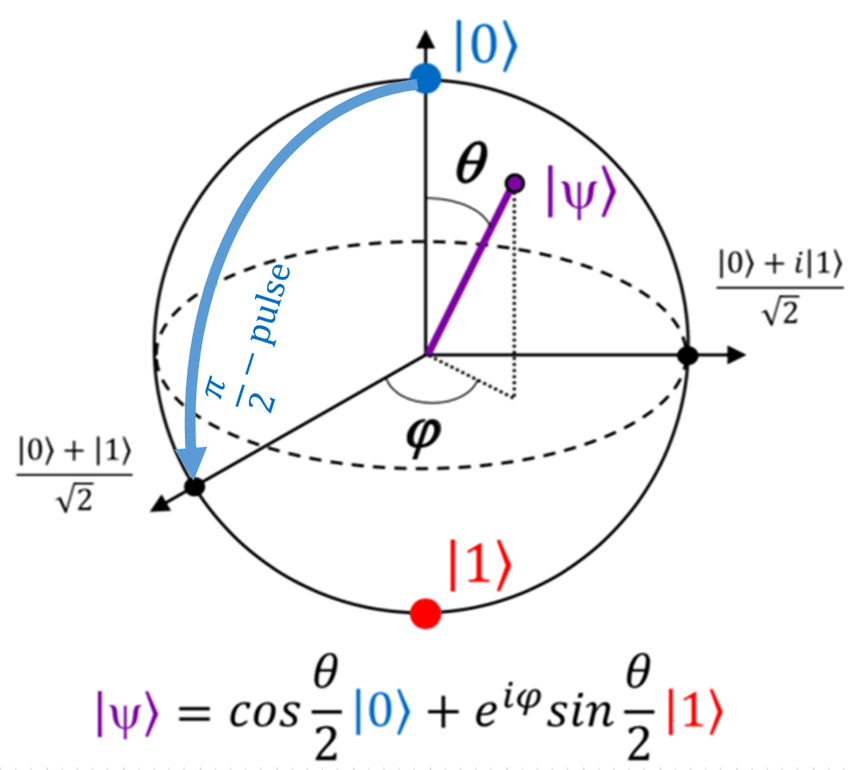

Denoting the Bloch sphere for calculations,

$|\psi⟩ = \cos\!\left(\frac{\theta}{2}\right)\,|0⟩ + e^{i\phi}\,\sin\!\left(\frac{\theta}{2}\right)\,|1⟩$

Recalling the complex number $z$,

$|\psi⟩ = a|0⟩ + b|1⟩$, where $a = \cos\!\left(\frac{\theta}{2}\right)\,$ and $b = e^{i\phi}\,\sin\!\left(\frac{\theta}{2}\right)\,$.

##### Calculating Probabilities

To determine the probabilities, let $N$ be the total counts of repeated measurements of the Qubit, where,

$N = n_0 + n_1$

Thus,

$\hat{P}(0) = \frac{n_0}{N}$ and $\hat{P}(1) = \frac{n_1}{N}$

Both denoting the probabilities of being `0` or `1` classical bit. _Note that if $\hat{P}(1) > \hat{P}(0)$ one cannot claim it is equals `1`, rather it is *biased* toward `1`, and for classical interpretation, it is considered as `1`._

##### Error Reduction with Measurements

Thus, given that the interpretation is probabilistic, it is ideal to take more measurements to determine a better accuracy,

$error \sim \frac{1}{\sqrt{N}}$

| Shots($N$) | Typical Error |
| -- | -- |
| 100 | ~10% |
| 1,000 | ~3% |
| 10,000 | ~1% |
| 1,000,000 | ~0.1% |

In [2]:
Aer.backends()

[AerSimulator('aer_simulator'),
 AerSimulator('aer_simulator_statevector'),
 AerSimulator('aer_simulator_density_matrix'),
 AerSimulator('aer_simulator_stabilizer'),
 AerSimulator('aer_simulator_matrix_product_state'),
 AerSimulator('aer_simulator_extended_stabilizer'),
 AerSimulator('aer_simulator_unitary'),
 AerSimulator('aer_simulator_superop'),
 QasmSimulator('qasm_simulator'),
 StatevectorSimulator('statevector_simulator'),
 UnitarySimulator('unitary_simulator')]

# 1. Understanding Gates Rotation

### 1.1 Understanding the Basic Gates

##### Pauli-X $X$ Gate

Refer: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.XGate

Matrix:

$
X = \begin{bmatrix}
0 & 1 \\
1 & 0
\end{bmatrix}
$

##### Pauli-Y $Y$ Gate

Refer: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.YGate

Matrix:

$
Y = \begin{bmatrix}
0 & -i \\
i & 0
\end{bmatrix}
$

##### Phase $Z$ Gate

Refer: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.ZGate

Matrix:
$
Z = \begin{bmatrix}
1 & 0 \\
0 & -1
\end{bmatrix}
$

##### Identity $I$ Gate

Refer: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.IGate

$
I = \begin{bmatrix}
1 & 0 \\
0 & 1
\end{bmatrix}
$

### 1.2 Starting with the Hadamard $H$ Gate

> Fundamental quantum operation used to put a qubit into an equal superposition of $|0⟩$ and $|1⟩$ (both states at once), enabling quantum parallelism and interference

Refer: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.HGate

Matrix:

$
H = \frac{1}{\sqrt{2}}
\begin{bmatrix}
1 & 1 \\
1 & -1
\end{bmatrix}
$

Truth Table:

| Input | Output |
| -- | -- |
| $0$ | $\frac{1}{\sqrt{2}}(\|0⟩ + \|1⟩)$ |
| $1$ | $\frac{1}{\sqrt{2}}(\|0⟩ - \|1⟩)$ |

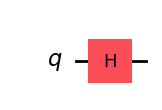

In [3]:
qc = QuantumCircuit(1)
qc.h(0)
qc.draw('mpl')

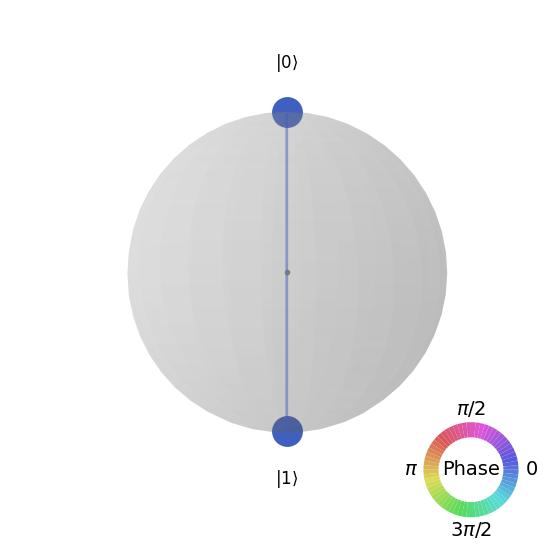

In [4]:
state = Statevector.from_instruction(qc)
plot_state_qsphere(qc)

Applying the Fundamental Gates for reference,

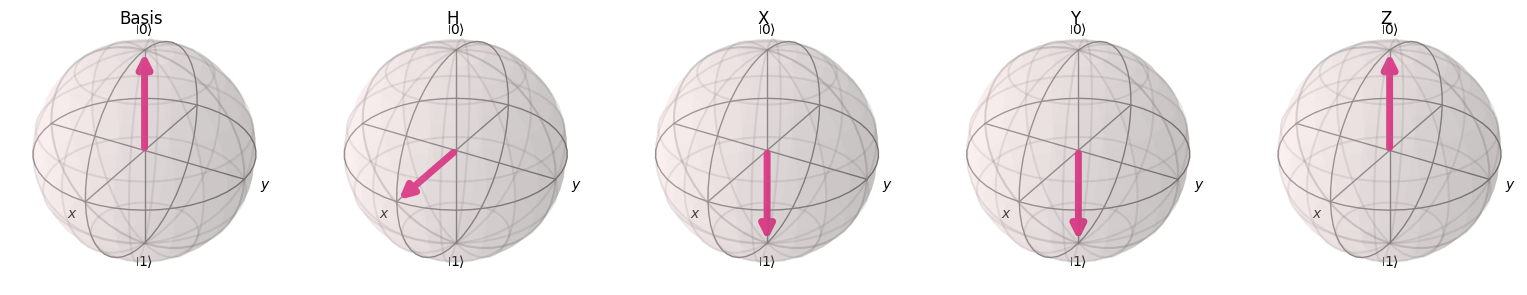

In [5]:
qc = QuantumCircuit(5)
qc.h(1)
qc.x(2)
qc.y(3)
qc.z(4)
state = Statevector.from_instruction(qc)
fig = plot_bloch_multivector(qc)
fig.axes[0].set_title("Basis", pad=15)
fig.axes[1].set_title("H", pad=15)
fig.axes[2].set_title("X", pad=15)
fig.axes[3].set_title("Y", pad=15)
fig.axes[4].set_title("Z", pad=15)
fig.tight_layout()
fig


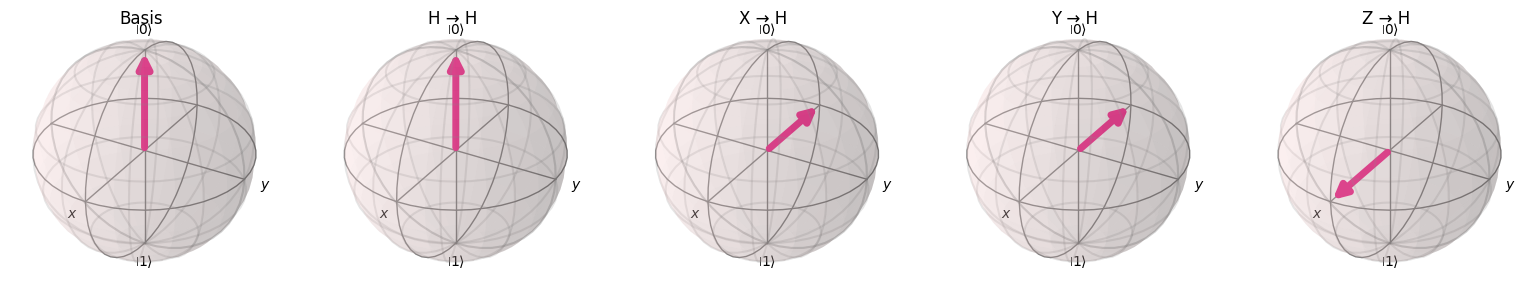

In [6]:
qc = QuantumCircuit(5)
qc.h(1)
qc.h(1)
qc.x(2)
qc.h(2)
qc.y(3)
qc.h(3)
qc.z(4)
qc.h(4)
state = Statevector.from_instruction(qc)
fig = plot_bloch_multivector(qc)
fig.axes[0].set_title("Basis", pad=15)
fig.axes[1].set_title("H → H", pad=15)
fig.axes[2].set_title("X → H", pad=15)
fig.axes[3].set_title("Y → H", pad=15)
fig.axes[4].set_title("Z → H", pad=15)
fig.tight_layout()
fig


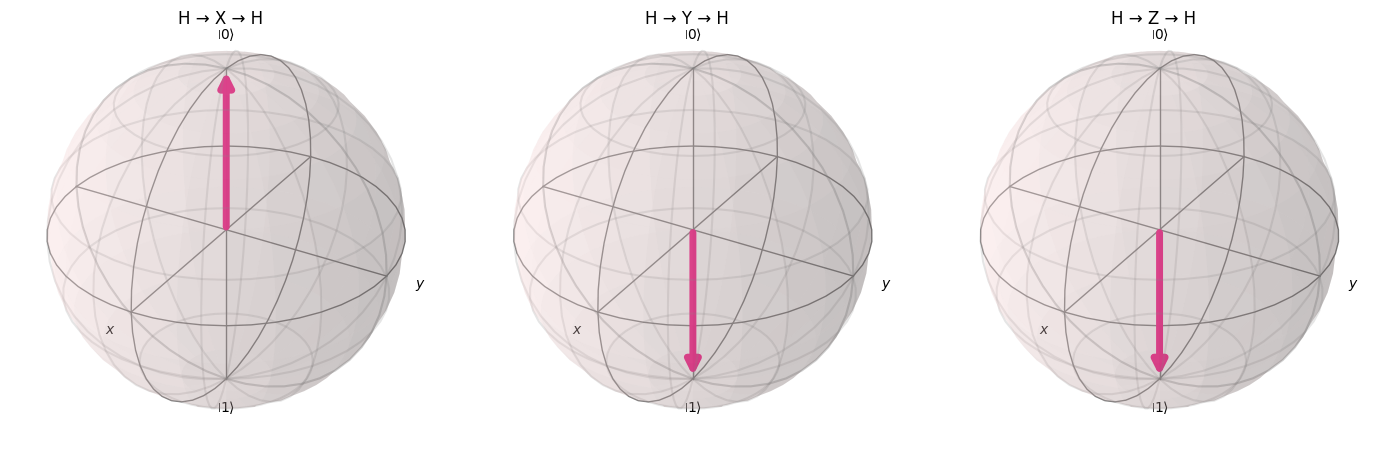

In [7]:
qc = QuantumCircuit(3)
qc.h(0)
qc.x(0)
qc.h(0)
qc.h(1)
qc.y(1)
qc.h(1)
qc.h(2)
qc.z(2)
qc.h(2)
state = Statevector.from_instruction(qc)
fig = plot_bloch_multivector(qc)
fig.axes[0].set_title("H → X → H", pad=25)
fig.axes[1].set_title("H → Y → H", pad=25)
fig.axes[2].set_title("H → Z → H", pad=25)
fig.tight_layout()
fig


Notice how $Z$ Phase Gate switches the direction,

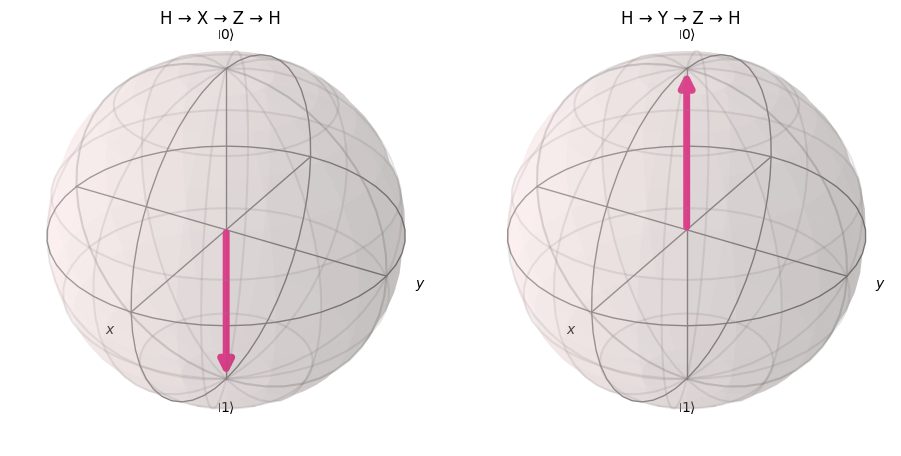

In [8]:
qc = QuantumCircuit(2)
qc.h(0)
qc.x(0)
qc.z(0)
qc.h(0)
qc.h(1)
qc.y(1)
qc.z(1)
qc.h(1)
state = Statevector.from_instruction(qc)
fig = plot_bloch_multivector(qc)
fig.axes[0].set_title("H → X → Z → H", pad=25)
fig.axes[1].set_title("H → Y → Z → H", pad=25)
fig.tight_layout()
fig


## 2. Phase and Bloch Sphere
### 2.1 Running on Simulators

In [9]:
import math
from qiskit.quantum_info import DensityMatrix, Statevector

In [10]:
qasm_simulator = Aer.get_backend('qasm_simulator')
statevector_simulator = Aer.get_backend('statevector_simulator')

In [11]:
def run_on_simulators(circuit):
    compiled_circuit = transpile(circuit, backend=statevector_simulator)
    job = statevector_simulator.run(compiled_circuit, shots=1024)
    result = job.result()
    statevec = result.get_statevector()
    num_qubits = circuit.num_qubits
    # r = [i for i in range(num_qubits)]
    # circuit.measure(r, r)
    circuit.measure_all()
    return result, statevec or Statevector([])

### 2.2 Running with $RX$ Rotate-$x$ Gate

> Rotates a qubit's state around the $x$-axis of the Qubit's Bloch sphere by a specified angle ($θ$), acting as a fundamental tool for state preparation, creating superpositions, and manipulating quantum information in quantum algorithms.

Refer: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.RXGate

Matrix:

$
RX(θ) = \begin{bmatrix}
cos(θ/2) & -i sin(θ/2) \\
-i sin(θ/2) & cos(θ/2)
\end{bmatrix}
$

### 2.3 Running with $RY$ Rotate-$y$ Gate

For the $RY$ Rotate-$y$ Gate on the $y$-axis,

Refer: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.RYGate

Matrix:

$
RY(θ) = \begin{bmatrix}
cos(θ/2) & -sin(θ/2) \\
sin(θ/2) & cos(θ/2)
\end{bmatrix}
$

### 2.4 Running with $RX$ Rotate-$z$ Gate

For the $RZ$ Rotate-$z$ Gate on the $z$-axis,

Refer: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.RZGate

Matrix:

$
RZ(φ) = \begin{bmatrix}
e^{-i\frac{φ}{2}} & 0 \\
0 & e^{i\frac{φ}{2}}
\end{bmatrix}
$





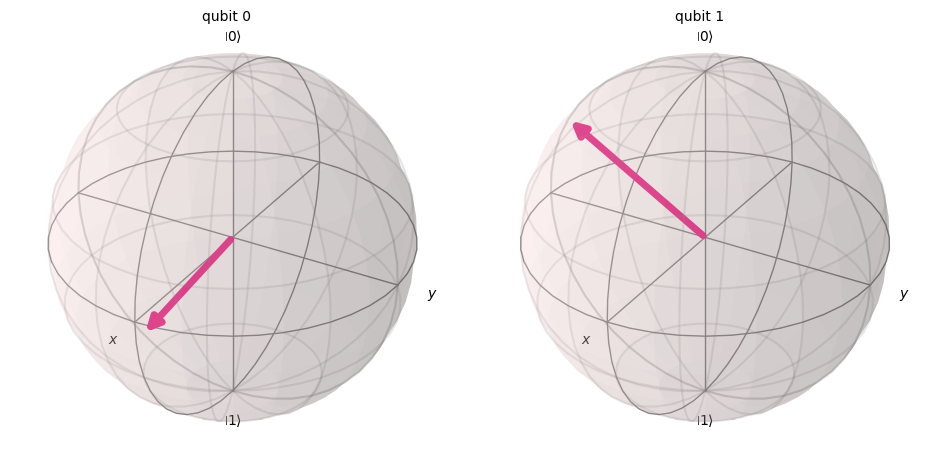

In [12]:
qc = QuantumCircuit(2,2)
qc.rx(-1.2*math.pi, 0)
qc.rx(math.pi/3, 1)
result, statevec = run_on_simulators(qc)
plot_bloch_multivector(statevec)

### 2.5 Understanding Phase Gate

1. Use Hadamard Gate itself first
2. Apply Phase Gate to see switch in direction

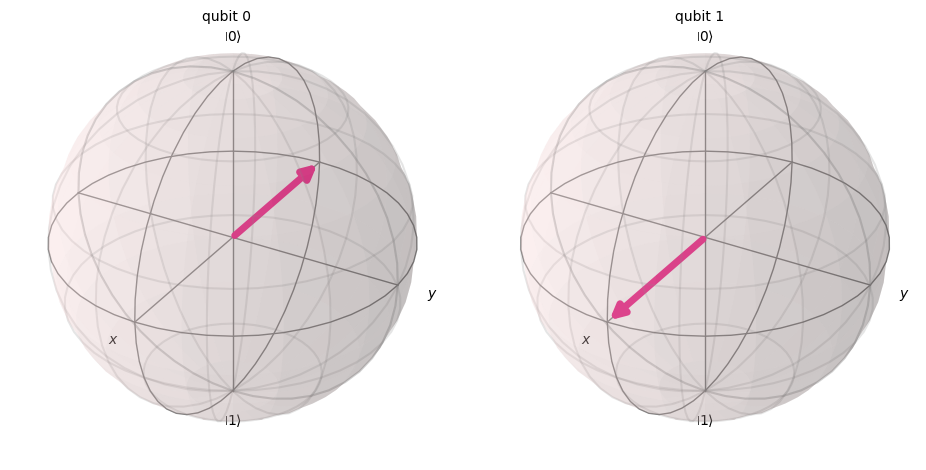

In [13]:
qc = QuantumCircuit(2,2)
qc.h(0)
qc.z(0)
qc.h(1)
result, statevec = run_on_simulators(qc)
plot_bloch_multivector(statevec)

### 2.6 Using the CNOT (Controlled NOT) Gate

> Fundamental two-qubit quantum logic gate that flips the state of a "target" qubit only if a "control" Qubit is in the $|1⟩$ state. This is also known as the Controlled Pauli-X Gate

Refer: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.CXGate

Matrix:

$
CX q_0, q_1 = I ⊗ ∣0⟩⟨0∣ + X ⊗ ∣1⟩⟨1∣ = \begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0 \\
0 & 1 & 0 & 0
\end{bmatrix}
$

Recall that $⊗$ is a tensor product,

$$
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
\otimes
\begin{bmatrix}
e & f \\
g & h
\end{bmatrix}
=
\begin{bmatrix}
ae & af & be & bf \\
ag & ah & bg & bh \\
ce & cf & de & df \\
cg & ch & dg & dh
\end{bmatrix}
$$

Truth Table:

| $x$ | $y$ | | $x$ | $x$ XOR $y$ |
| -- | -- | -- | -- | -- |
| 0 | 0 | | 0 | 0 |
| 0 | 1 | | 0 | 1 |
| 1 | 0 | | 1 | 1 |
| 1 | 1 | | 1 | 0 |

In [14]:
qc = QuantumCircuit(2,2)
qc.h(0)
#qc.rx(math.pi * 4/5, 0)
result, statevec = run_on_simulators(qc)
print(result.get_counts())

{'00': 1024}


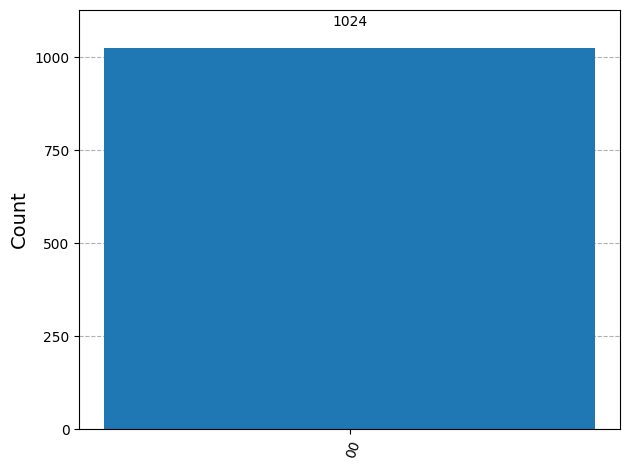

In [15]:
plot_histogram(result.get_counts())

In [16]:
qc.cx(0, 1)
result, statevec = run_on_simulators(qc)
print(result.get_counts())

{'00 00': 521, '01 00': 503}


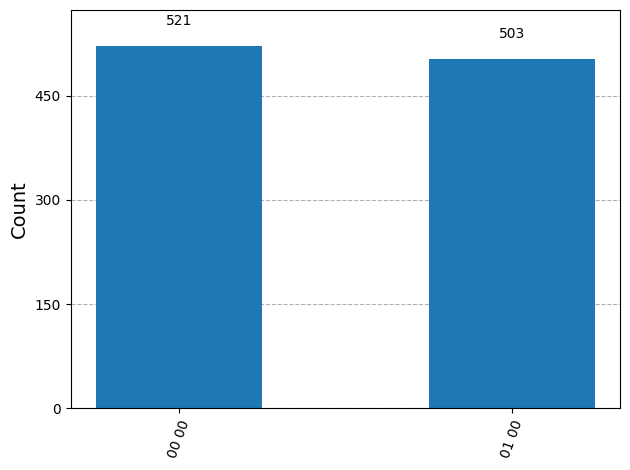

In [17]:
plot_histogram(result.get_counts())

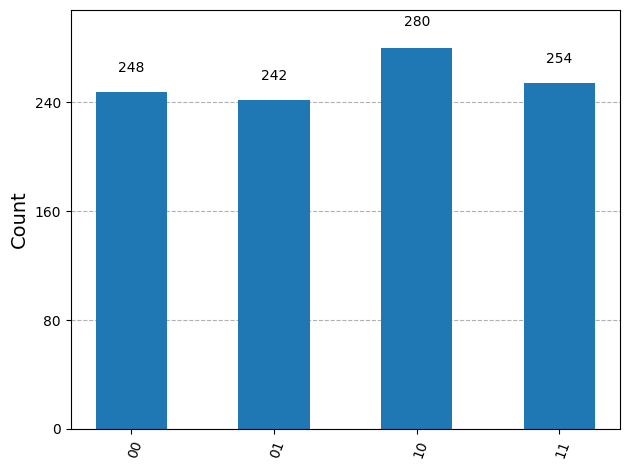

In [18]:
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.h(1)
qc.measure([0, 1], [0, 1])
result, statevec = run_on_simulators(qc)
plot_histogram(result.get_counts())